In [2]:
import pandas as pd
import numpy as np

# 1. np.random.seed ensures we get the same "random" numbers every time we run this.
# This makes our experiment repeatable.
np.random.seed(42)

# 2. We are creating 1,000 "snapshots" of a flight.
n_samples = 1000

# airspeed: Generate 1,000 random speeds between 40 and 250 knots.
# A small plane typically stalls around 50-60 knots.
airspeed = np.random.uniform(40, 250, n_samples)

# angle_of_attack: Generate 1,000 random wing angles between 0 and 20 degrees.
# A high angle (usually above 15°) causes the wing to lose lift (stall).
angle_of_attack = np.random.uniform(0, 20, n_samples)

# 3. This is the "Physics Rule."
# We tell the computer: IF speed < 60 AND angle > 15, mark it as a Stall (1).
# Otherwise, mark it as Safe (0).
is_stalling = ((airspeed < 60) & (angle_of_attack > 15)).astype(int)

# 4. We put this data into a "DataFrame" (essentially an Excel table).
flight_data = pd.DataFrame({
    'Airspeed_Knots': airspeed,
    'Angle_of_Attack': angle_of_attack,
    'Stall_Warning': is_stalling
})

# 5. This prints the first 10 rows of our flight recorder so we can see it.
print("--- Flight Data Table ---")
print(flight_data.head(10))

# 6. This counts how many "Stalls" happened in our 1,000 samples.
print("\nNumber of Stall incidents detected:")
print(flight_data['Stall_Warning'].value_counts())

--- Flight Data Table ---
   Airspeed_Knots  Angle_of_Attack  Stall_Warning
0      118.653425         3.702659              0
1      239.650004        10.838019              0
2      193.718728        17.458917              0
3      165.718282        14.644498              0
4       72.763914        16.131223              0
5       72.758849        13.175667              0
6       52.197559        13.845531              0
7      221.896991        16.983913              0
8      166.234152         4.993360              0
9      188.695241         9.788499              0

Number of Stall incidents detected:
Stall_Warning
0    974
1     26
Name: count, dtype: int64


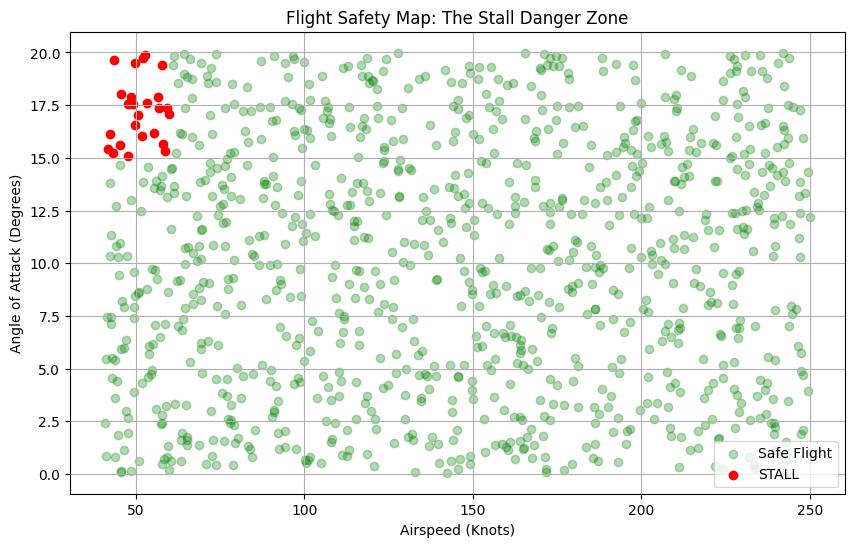

In [3]:
import matplotlib.pyplot as plt

# 1. Create the figure size
plt.figure(figsize=(10, 6))

# 2. Plot the "Safe" points in Green
safe = flight_data[flight_data['Stall_Warning'] == 0]
plt.scatter(safe['Airspeed_Knots'], safe['Angle_of_Attack'], c='green', alpha=0.3, label='Safe Flight')

# 3. Plot the "Stall" points in Red
stalls = flight_data[flight_data['Stall_Warning'] == 1]
plt.scatter(stalls['Airspeed_Knots'], stalls['Angle_of_Attack'], c='red', alpha=1.0, label='STALL')

# 4. Add labels so we know what we are looking at
plt.xlabel('Airspeed (Knots)')
plt.ylabel('Angle of Attack (Degrees)')
plt.title('Flight Safety Map: The Stall Danger Zone')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Define X (Features: what the AI looks at) and y (Target: what the AI predicts)
X = flight_data[['Airspeed_Knots', 'Angle_of_Attack']]
y = flight_data['Stall_Warning']

# 2. Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Decision Tree (The "Brain")
model = DecisionTreeClassifier()

# 4. TEACH the AI: This is where it looks at the data and "learns" the patterns
model.fit(X_train, y_train)

# 5. TEST the AI: Let it predict the outcomes for the data it hasn't seen yet
predictions = model.predict(X_test)

# 6. Check the score
score = accuracy_score(y_test, predictions)
print(f"AI Model Accuracy: {score * 100:.2f}%")

AI Model Accuracy: 100.00%


In [5]:
# Phase 4: Manual Pilot Test
# Change these two numbers to test your AI!
my_speed = 60
my_angle = 14

# 1. We put your numbers into a tiny table so the AI can read them
test_input = pd.DataFrame([[my_speed, my_angle]], columns=['Airspeed_Knots', 'Angle_of_Attack'])

# 2. The AI makes its prediction (0 for Safe, 1 for Stall)
result = model.predict(test_input)

# 3. We print the human-friendly result
if result[0] == 1:
    print(f"⚠️ STALL WARNING! At {my_speed} knots and {my_angle}°, the AI predicts a loss of lift.")
else:
    print(f"✅ STABLE FLIGHT. At {my_speed} knots and {my_angle}°, the AI says you are flying safely.")

✅ STABLE FLIGHT. At 60 knots and 14°, the AI says you are flying safely.
